# Predicting Movie Financial Success
### DS 2500 Project

“Can a movie’s budget, runtime, and genres predict whether it earns its money back?”


## Loading the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, classification_report

try:
    from google.colab import drive
    drive.mount('/content/drive')
    filepath = "/content/drive/My Drive/DS2500/Project/tmdb_5000_movies.csv"
    data = pd.read_csv(filepath)
    print("Loaded file from Google Drive.")
except:
    filepath = "tmdb_5000_movies.csv"
    df = pd.read_csv(filepath)
    print("Loaded file from local directory.")

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded file from Google Drive.


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## Clean the data

A lot of columns use 0. Since I'm comparing budget to revenue, I dropped any row where budget, revenue, or runtime was missing (alongside vote_count and release dates)

In [ ]:
data_clean = data.drop(index=data[data['budget'] == 0].index, errors='ignore')       # drop budgets of 0
data_clean = data_clean.drop(index=data[data['revenue'] == 0].index, errors='ignore') # drop revenues of 0
data_clean = data_clean.drop(index=data[data['runtime'] == 0].index, errors='ignore')
data_clean = data_clean.drop(index=data[data['vote_count'] == 0].index, errors='ignore')
data_clean = data_clean.drop(index=data[data['release_date'].isna()].index, errors='ignore')

print("Cleaned shape:", data_clean.shape)
data_clean.describe(include='all')

Cleaned shape: (3227, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
count,3.227000e+03,3227,1345,3227.000000,3227,3227,3227,3227,3227.000000,3227,3227,3227,3.227000e+03,3227.000000,3227,3227,2983,3227,3227.000000,3227.000000
unique,NaN,933,1324,NaN,3097,27,3227,3227,NaN,2631,319,2494,NaN,NaN,439,2,2975,3226,NaN,NaN
top,NaN,"[{""id"": 18, ""name"": ""Drama""}]",http://www.thehungergames.movie/,NaN,[],en,El Mariachi,El Mariachi just wants to play his guitar and ...,NaN,"[{""name"": ""Paramount Pictures"", ""id"": 4}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2014-12-25,NaN,NaN,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,From zero to hero.,The Host,NaN,NaN
freq,NaN,203,4,NaN,97,3100,1,1,NaN,48,2148,7,NaN,NaN,2135,3226,2,2,NaN,NaN
mean,4.067877e+07,NaN,NaN,44601.870778,NaN,NaN,NaN,NaN,29.051491,NaN,NaN,NaN,1.213181e+08,110.720793,NaN,NaN,NaN,NaN,6.313263,977.893090
std,4.439974e+07,NaN,NaN,74281.771931,NaN,NaN,NaN,NaN,36.169863,NaN,NaN,NaN,1.863361e+08,20.970364,NaN,NaN,NaN,NaN,0.859921,1414.538507
min,1.000000e+00,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,0.019984,NaN,NaN,NaN,5.000000e+00,41.000000,NaN,NaN,NaN,NaN,2.300000,1.000000
25%,1.050000e+07,NaN,NaN,4954.500000,NaN,NaN,NaN,NaN,10.475904,NaN,NaN,NaN,1.704008e+07,96.000000,NaN,NaN,NaN,NaN,5.800000,178.000000
50%,2.500000e+07,NaN,NaN,11442.000000,NaN,NaN,NaN,NaN,20.415572,NaN,NaN,NaN,5.519828e+07,107.000000,NaN,NaN,NaN,NaN,6.300000,471.000000
75%,5.500000e+07,NaN,NaN,45256.000000,NaN,NaN,NaN,NaN,37.345773,NaN,NaN,NaN,1.463949e+08,121.000000,NaN,NaN,NaN,NaN,6.900000,1148.000000


## Features

### Date features
`release_date` starts out as plain text, so I turned it into an actual date and pulled the year, month, and day of the week out of it.

In [ ]:
data_clean['release_date'] = pd.to_datetime(data_clean['release_date'])
data_clean['release_year'] = data_clean['release_date'].dt.year
data_clean['release_month_name'] = data_clean['release_date'].dt.month_name()
data_clean['release_day_name'] = data_clean['release_date'].dt.day_name()

data_clean[['title', 'release_date', 'release_year', 'release_month_name', 'release_day_name']].head()

,title,release_date,release_year,release_month_name,release_day_name
0,Avatar,2009-12-10,2009,December,Thursday
1,Pirates of the Caribbean: At World's End,2007-05-19,2007,May,Saturday
2,Spectre,2015-10-26,2015,October,Monday
3,The Dark Knight Rises,2012-07-16,2012,July,Monday
4,John Carter,2012-03-07,2012,March,Wednesday


###  Genre feature

`genres` comes in as a string that looks like a list of dictionaries (e.g. `[{"id": 28, "name": "Action"}]`)


I only kept the first genre listed for each movie. I know this is a limitation, but keeping it simple for this project.

In [ ]:
primary_genre_list = []
for genres_string in data_clean['genres']:
    genre_dicts = eval(genres_string)
    if len(genre_dicts) > 0:
        primary_genre_list.append(genre_dicts[0]['name'])
    else:
        primary_genre_list.append(None)

data_clean['primary_genre'] = primary_genre_list

no_genre_index = data_clean[data_clean['primary_genre'].isna()].index
data_clean = data_clean.drop(index=no_genre_index)

data_clean['primary_genre'].value_counts()

,count
primary_genre,
Drama,745
Comedy,634
Action,588
Adventure,288
Horror,197
Crime,141
Thriller,118
Animation,99
Fantasy,93


### Scaling budget and revenue

Budget and revenue are both really skewed. Taking the log10 of both makes the numbers easier to work with and plot.

In [ ]:
data_clean['budget_log'] = np.log10(data_clean['budget'])
data_clean['revenue_log'] = np.log10(data_clean['revenue'])

data_clean[['budget', 'budget_log', 'revenue', 'revenue_log']].head()

,budget,budget_log,revenue,revenue_log
0,237000000,8.374748,2787965087,9.445287
1,300000000,8.477121,961000000,8.982723
2,245000000,8.389166,880674609,8.944815
3,250000000,8.397940,1084939099,9.035405
4,260000000,8.414973,284139100,8.453531


###  Target label: hit or flop

This is the label I'm actually trying to predict. If a movie's revenue is at least its budget, I'm calling it a hit; otherwise it's a flop.

In [ ]:
hit_or_flop_list = []
for row_label in data_clean.index:
    revenue_value = data_clean['revenue'][row_label]
    budget_value = data_clean['budget'][row_label]
    if revenue_value >= budget_value:
        hit_or_flop_list.append(1)  # made money back
    else:
        hit_or_flop_list.append(0)  # flop


data_clean['hit_or_flop'] = hit_or_flop_list

total_movies = len(data_clean)
hit_count = (data_clean['hit_or_flop'] == 1).sum()
flop_count = (data_clean['hit_or_flop'] == 0).sum()

print("hit %:", hit_count / total_movies)
print("flop %:", flop_count / total_movies)

Proportion hit: 0.7563546187228767
Proportion flop: 0.24364538127712337


## Exploratory visualizations
What does the money side of things look like, and does budget, genre, or runtime seem connected to success at all?

### Revenue distribution (normal vs. log scale)
Comparison between normal data vs log data

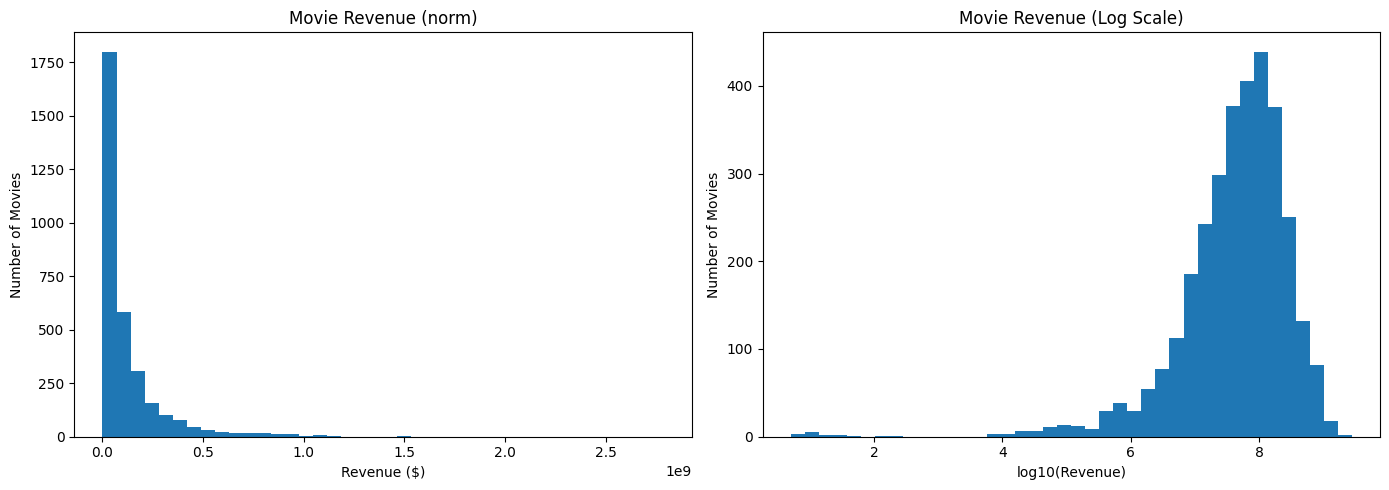

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data_clean['revenue'], bins=50)
axes[0].set_title('Movie Revenue (norm)')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Number of Movies')

axes[1].hist(data_clean['revenue_log'], bins=50)
axes[1].set_title('Movie Revenue (Log Scale)')
axes[1].set_xlabel('log10(Revenue)')
axes[1].set_ylabel('Number of Movies')

plt.tight_layout()
plt.show()

### Budget by genre (boxplot)
Just checking if certain genres tend to get bigger budgets than others.

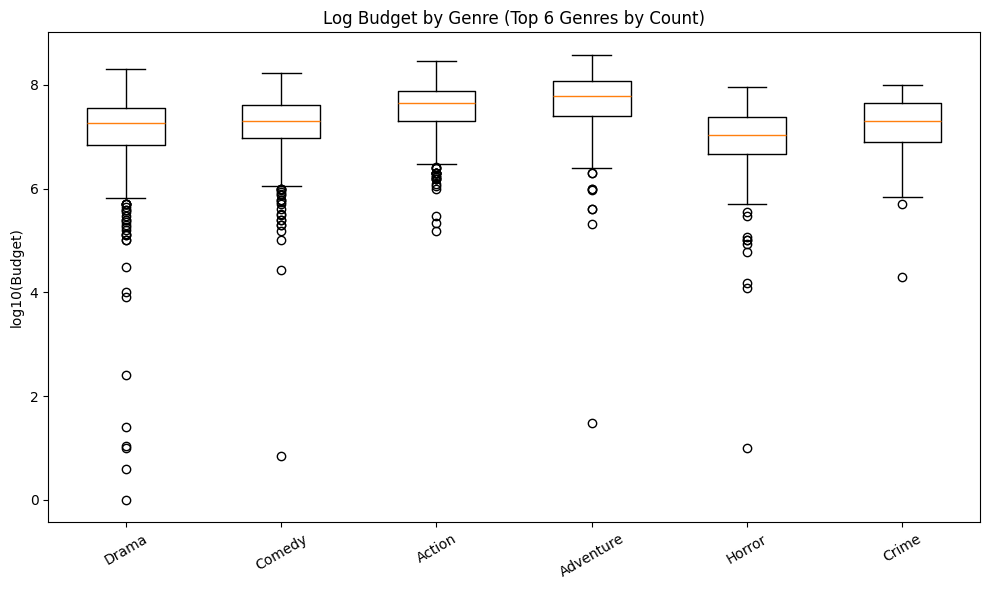

In [ ]:
top_genres = data_clean['primary_genre'].value_counts().head(6).index
genre_budget_data = [data_clean[data_clean['primary_genre'] == g]['budget_log'] for g in top_genres]

plt.figure(figsize=(10, 6))
plt.boxplot(genre_budget_data, tick_labels=list(top_genres))
plt.title('Log Budget by Genre (Top 6 Genres by Count)')
plt.ylabel('log10(Budget)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Budget vs. revenue (scatter)
The main relationship I care about: does spending more actually mean earning more back, or is it pretty noisy?

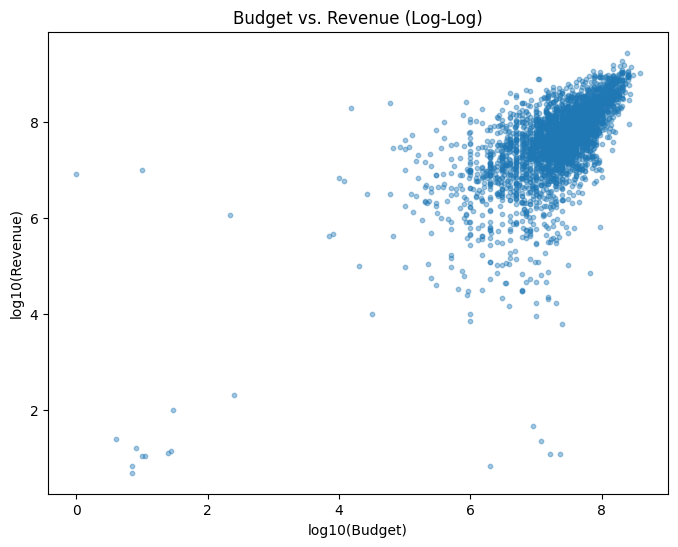

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(data_clean['budget_log'], data_clean['revenue_log'], alpha=0.4, s=10)
plt.title('Budget vs. Revenue (Log-Log)')
plt.xlabel('log10(Budget)')
plt.ylabel('log10(Revenue)')
plt.show()

## KNN (predicting hit vs. flop)

This is the main model for my project question. I'm using `budget_log`, `runtime`, and genre as features (not revenue because it gives the answer).

In [ ]:
genre_dummies = pd.get_dummies(data_clean['primary_genre'], prefix='genre')
for column in genre_dummies.columns:
    data_clean[column] = genre_dummies[column]

feature_columns = ['budget_log', 'runtime'] + list(genre_dummies.columns)
X_clf = data_clean[feature_columns]
y_clf = data_clean['hit_or_flop']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_val.shape[0])
print("Test rows:", X_test.shape[0])

budget_mean = X_train['budget_log'].mean()
budget_std = X_train['budget_log'].std()
runtime_mean = X_train['runtime'].mean()
runtime_std = X_train['runtime'].std()

X_train['budget_log'] = (X_train['budget_log'] - budget_mean) / budget_std
X_val['budget_log'] = (X_val['budget_log'] - budget_mean) / budget_std
X_test['budget_log'] = (X_test['budget_log'] - budget_mean) / budget_std

X_train['runtime'] = (X_train['runtime'] - runtime_mean) / runtime_std
X_val['runtime'] = (X_val['runtime'] - runtime_mean) / runtime_std
X_test['runtime'] = (X_test['runtime'] - runtime_mean) / runtime_std

Training rows: 1935
Validation rows: 645
Test rows: 646


### Finding the best k






In [ ]:
best_f1 = 0
best_k = None

for k in range(3, 32, 2):  # odd k values from 3 to 31
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)

    val_predictions = knn_model.predict(X_val)
    f1_flop = f1_score(y_val, val_predictions, pos_label=0)

    if f1_flop > best_f1:
        best_f1 = f1_flop
        best_k = k

print(f"Best K: {best_k}")

Best K: 5


### 5b. Final eval using the chosen k


In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print("KNN Precision (flop):", precision_score(y_test, knn_preds, pos_label=0))
print("KNN Recall (flop):", recall_score(y_test, knn_preds, pos_label=0))
print("KNN F1 (flop):", f1_score(y_test, knn_preds, pos_label=0))

print(classification_report(y_test, knn_preds))

KNN Accuracy: 0.7198142414860681
KNN Precision (flop): 0.3125
KNN Recall (flop): 0.12738853503184713
KNN F1 (flop): 0.18099547511312217
              precision    recall  f1-score   support

           0       0.31      0.13      0.18       157
           1       0.76      0.91      0.83       489

    accuracy                           0.72       646
   macro avg       0.54      0.52      0.51       646
weighted avg       0.65      0.72      0.67       646



## Logistic Regression (predicting hit vs. flop)



In [ ]:
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)
logreg_preds = logreg_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_preds))
print("Logistic Regression Precision (flop):", precision_score(y_test, logreg_preds, pos_label=0, zero_division=0))
print("Logistic Regression Recall (flop):", recall_score(y_test, logreg_preds, pos_label=0))
print("Logistic Regression F1 (flop):", f1_score(y_test, logreg_preds, pos_label=0))

Logistic Regression Accuracy: 0.7569659442724458
Logistic Regression Precision (flop): 0.0
Logistic Regression Recall (flop): 0.0
Logistic Regression F1 (flop): 0.0


## Linear Regression (predicting revenue)



In [ ]:
feature_columns_reg = ['budget_log', 'runtime'] + list(genre_dummies.columns)
X_reg = data_clean[feature_columns_reg]
y_reg = data_clean['revenue_log']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(Xr_train, yr_train)
yr_preds = lin_model.predict(Xr_test)

print("Linear Regression R2:", r2_score(yr_test, yr_preds))

mae = np.mean(np.abs(yr_test - yr_preds))
print("Linear Regression MAE (log revenue):", mae)

Linear Regression R2: 0.5772382231201345
Linear Regression MAE (log revenue): 0.4201670118672825


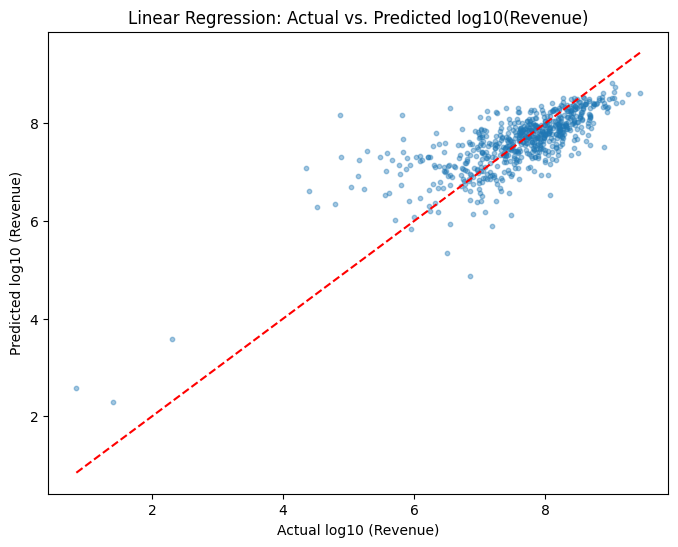

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(yr_test, yr_preds, alpha=0.4, s=10)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.title('Linear Regression: Actual vs. Predicted log10(Revenue)')
plt.xlabel('Actual log10 (Revenue)')
plt.ylabel('Predicted log10 (Revenue)')
plt.show()